# AlexNet

AlexNet本质上是一个更大更深的LeNet，通过卷积层和池化层的堆叠，实现了更复杂的特征提取，最后接全连接层接Dropout层进行输出。

他的参数都是调出来的

激活函数从sigmoid切换成ReLU，防止深层网络出现梯度消失问题

## 模型定义

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    # 这里使用一个11*11的更大窗口来捕捉对象。
    # 同时，步幅为4，以减少输出的高度和宽度。
    # 另外，输出通道的数目远大于LeNet
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),  # 这个参数的设置是测试出来的
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    # 使用三个连续的卷积层和较小的卷积窗口。
    # 除了最后的卷积层，输出通道的数量进一步增加。
    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
    nn.Linear(4096, 10))

c:\Users\20249\.conda\envs\test1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


看一下上面的全连接层是怎么得到计算结果的：
在 PyTorch 中，卷积层和池化层的输出尺寸计算公式为（向下取整）：

$$Output = \lfloor \frac{Input + 2 \times Padding - Kernel\_Size}{Stride} \rfloor + 1$$

这里公式的+1是因为要考虑初始位置的输出

以下是逐层的空间尺寸（以高/宽为例，因为输入是 $224 \times 224$ 的正方形）推导过程：

初始输入:尺寸: $224 \times 224$

第一个卷积层 nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1):计算: $\lfloor \frac{224 + 2 \times 1 - 11}{4} \rfloor + 1 = \lfloor \frac{215}{4} \rfloor + 1 = 53 + 1 = 54$此时特征图形状: $96 \times 54 \times 54$

第一个pooling nn.MaxPool2d(kernel_size=3, stride=2):计算: $\lfloor \frac{54 + 2 \times 0 - 3}{2} \rfloor + 1 = \lfloor \frac{51}{2} \rfloor + 1 = 25 + 1 = 26$此时特征图形状: $96 \times 26 \times 26$

第二个卷积层 nn.Conv2d(96, 256, kernel_size=5, padding=2) (PyTorch 中默认 stride=1):计算: $\lfloor \frac{26 + 2 \times 2 - 5}{1} \rfloor + 1 = 26 + 4 - 5 + 1 = 26$ (通过 padding=2 保持了尺寸不变)此时特征图形状: $256 \times 26 \times 26$

第二个pooling nn.MaxPool2d(kernel_size=3, stride=2):计算: $\lfloor \frac{26 + 2 \times 0 - 3}{2} \rfloor + 1 = \lfloor \frac{23}{2} \rfloor + 1 = 11 + 1 = 12$此时特征图形状: $256 \times 12 \times 12$连续的

三个卷积层:nn.Conv2d(256, 384, kernel=3, padding=1)nn.Conv2d(384, 384, kernel=3, padding=1)nn.Conv2d(384, 256, kernel=3, padding=1)这里的 kernel=3 且 padding=1 时，空间维度保持不变。此时特征图形状: $256 \times 12 \times 12$

最后一个pooling nn.MaxPool2d(kernel_size=3, stride=2):计算: $\lfloor \frac{12 + 2 \times 0 - 3}{2} \rfloor + 1 = \lfloor \frac{9}{2} \rfloor + 1 = 4 + 1 = 5$此时特征图形状: $256 \times 5 \times 5$

展平层 nn.Flatten():将多维的张量拉平成一维向量以输入全连接层。

长度计算: $256 \text{ (通道)} \times 5 \text{ (高)} \times 5 \text{ (宽)} = \mathbf{6400}$

看一下网络结构：

In [2]:
X = torch.randn((1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, X.shape)

Conv2d torch.Size([1, 96, 54, 54])
ReLU torch.Size([1, 96, 54, 54])
MaxPool2d torch.Size([1, 96, 26, 26])
Conv2d torch.Size([1, 256, 26, 26])
ReLU torch.Size([1, 256, 26, 26])
MaxPool2d torch.Size([1, 256, 12, 12])
Conv2d torch.Size([1, 384, 12, 12])
ReLU torch.Size([1, 384, 12, 12])
Conv2d torch.Size([1, 384, 12, 12])
ReLU torch.Size([1, 384, 12, 12])
Conv2d torch.Size([1, 256, 12, 12])
ReLU torch.Size([1, 256, 12, 12])
MaxPool2d torch.Size([1, 256, 5, 5])
Flatten torch.Size([1, 6400])
Linear torch.Size([1, 4096])
ReLU torch.Size([1, 4096])
Dropout torch.Size([1, 4096])
Linear torch.Size([1, 4096])
ReLU torch.Size([1, 4096])
Dropout torch.Size([1, 4096])
Linear torch.Size([1, 10])


## 读取数据集

In [3]:
d2l.get_dataloader_workers = lambda: 0
batch_size = 32
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)  # Resize 对图片进行放缩，放到228尺度

## 训练

直接调用之前编写好的函数，进行封装

training on cuda:0


RuntimeError: CUDA out of memory. Tried to allocate 2.00 MiB (GPU 0; 2.00 GiB total capacity; 476.88 MiB already allocated; 0 bytes free; 546.00 MiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

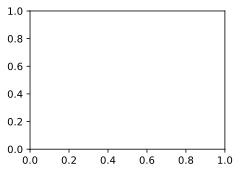

In [4]:
lr, num_epochs = 0.01, 10
d2l.train_ch6(net, train_iter, test_iter,num_epochs, lr, d2l.try_gpu())